In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle
import globals as gl
import pandas as pd
from scipy.stats import pearsonr, spearmanr, ttest_1samp
import seaborn as sb

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [2]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp']
epochs = ['Pre', 'SLR', 'LLR', 'Vol']
H = 'L'
freqs = ['alpha', 'beta', 'gamma']
time_interval = ['early', 'late']
experiment1 = 'smp0'
experiment2 = 'smp2'

Pre: r=-0.9999999926874557, [-1.0, 0.9999999344186318]
SLR: r=-0.0361433793567134, [-0.9999999998012432, 0.7192578263445658]
LLR: r=0.646110329902124, [0.3695791768779622, 0.849663525417246]
Vol: r=0.7740201256714457, [0.673095154957245, 0.8964131714429286]


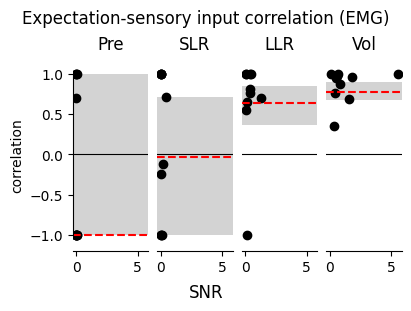

In [3]:
df_corr_emg = pd.read_csv(os.path.join(gl.baseDir, experiment1, gl.pcmDir, 'correlations.EMG.tsv'), sep='\t')

fig, axs = plt.subplots(1, len(epochs), sharex=True, sharey=True, figsize=(4, 3), constrained_layout=True)

for e, epoch in enumerate(epochs):
    ax = axs[e]
    df_corr_tmp = df_corr_emg[(df_corr_emg['epoch'] == epoch)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    print(f'{epoch}: r={r_group}, [{ci_lo}, {ci_hi}]')
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if e == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(epoch)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Expectation-sensory input correlation (EMG)')

plt.show()


SMA: r=-0.9999999999906444, [-1.0, -0.9999999966345332]
PMd: r=-0.9999999999999182, [-1.0, -0.9999999977243712]
PMv: r=-0.999999999999805, [-0.9999999999999996, -0.99999997026955]
M1: r=-0.8232093652196346, [-1.0, -0.6850746790071263]
S1: r=-0.6134584479664559, [-0.9327735814642816, -0.536031432583643]
SPLa: r=-0.9999999999998316, [-0.9999999999999551, -0.9999999829220148]
SPLp: r=-0.9999999923223722, [-0.9999999999999736, -0.9999999973893466]


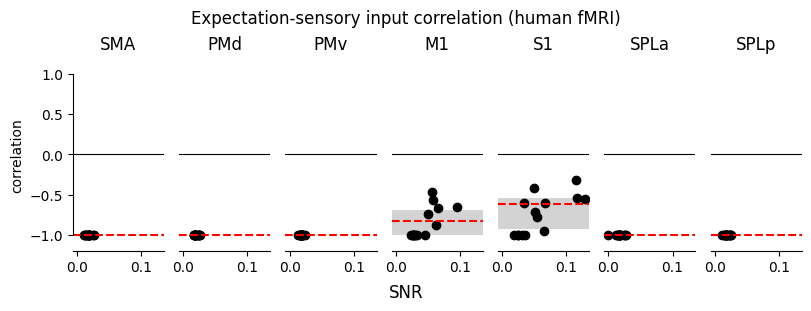

In [4]:
df_corr_bold = pd.read_csv(os.path.join(gl.baseDir, experiment2, gl.pcmDir, 'correlations.BOLD.tsv'), sep='\t')
corr = 'cue-finger'
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(8, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]
    df_corr_tmp = df_corr_bold[(df_corr_bold['roi'] == roi) & (df_corr_bold['Hem'] == H) & (df_corr_bold['corr'] == corr)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    print(f'{roi}: r={r_group}, [{ci_lo}, {ci_hi}]')
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if r == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Expectation-sensory input correlation (human fMRI)')

plt.show()


alpha: r=0.0719297874477002, [-0.4319165941513781, 0.7791305428824261]
beta: r=-0.7628800845598983, [-1.0, -0.3595200059340832]
gamma: r=-0.9469992443210224, [-1.0, -0.6589124701488683]


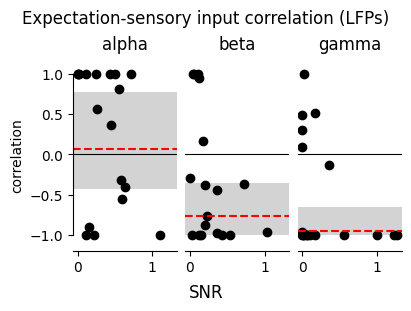

In [5]:
df_corr_lfp = pd.read_csv(os.path.join(gl.nhpDir, gl.pcmDir, 'correlations.lfp.tsv'), sep='\t')

fig, axs = plt.subplots(1, len(freqs), sharex=True, sharey=True, figsize=(4, 3), constrained_layout=True)

for f, freq in enumerate(freqs):
    ax = axs[f]
    df_corr_tmp = df_corr_lfp[(df_corr_lfp['freq'] == freq)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    print(f'{freq}: r={r_group}, [{ci_lo}, {ci_hi}]')
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if f == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(freq)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Expectation-sensory input correlation (LFPs)')

plt.show()


early: r=0.4074837857934948, [0.2807946587534991, 0.5032685913852967]
late: r=0.3208748054254555, [0.1548391021522324, 0.5182783870779073]


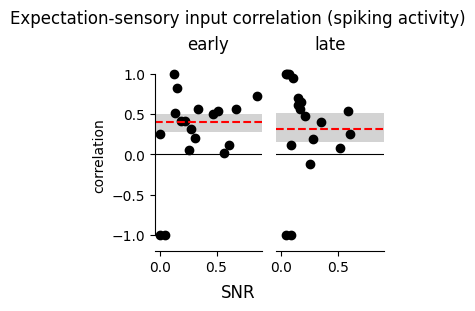

In [6]:
df_corr_spk = pd.read_csv(os.path.join(gl.nhpDir, gl.pcmDir, 'correlations.spk.tsv'), sep='\t')

fig, axs = plt.subplots(1, len(time_interval), sharex=True, sharey=True, figsize=(3, 3), constrained_layout=True)

for t, ti in enumerate(time_interval):
    ax = axs[t]
    df_corr_tmp = df_corr_spk[(df_corr_spk['time_interval'] == ti)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    print(f'{ti}: r={r_group}, [{ci_lo}, {ci_hi}]')
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if t == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(ti)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Expectation-sensory input correlation (spiking activity)')

plt.show()


AttributeError: 'DataFrame' object has no attribute 'lfp'

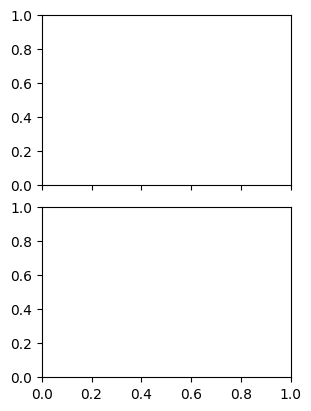

In [7]:
fig, axs = plt.subplots(2, sharex=True, figsize=(3, 4), constrained_layout=True)

df_excr = pd.read_csv(os.path.join(gl.nhpDir, gl.behavDir, 'excursion.tsv'), sep='\t')
df_excr.lfp = np.abs(df_excr.lfp)
df_excr = df_excr[((df_excr['roi'] == 'M1') | (df_excr['roi'] == 'S1'))]
df_excr_grouped = df_excr.groupby(['roi', 'cond', 'session']).mean(numeric_only=True).reset_index()
sb.barplot(x='cond', y='lfp', data=df_excr_grouped, errorbar='se', ax=axs[0])
sb.barplot(x='cond', y='excr_peak', data=df_excr_grouped, errorbar='se', ax=axs[1])

plt.show()

SignificanceResult(statistic=np.float64(0.3279181552236136), pvalue=np.float64(7.362224286603302e-18))


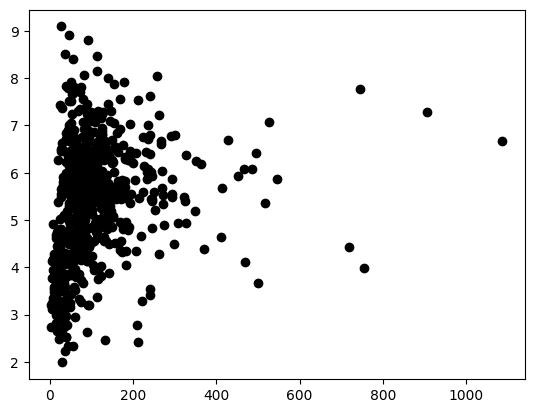

In [140]:
df_excr = pd.read_csv(os.path.join(gl.nhpDir, gl.behavDir, 'excursion.tsv'), sep='\t')
excr = np.load(os.path.join(gl.nhpDir, gl.behavDir, 'excursion.npy'))
pe = np.load(os.path.join(gl.nhpDir, gl.behavDir, 'PE.npy'))
idx = ((df_excr['roi'] == 'M1')) & ((df_excr['cond'] == 4) | (df_excr['cond'] == 5))
df_excr = df_excr[idx]
excr = excr[idx]
pe = np.abs(pe[idx])
peak_excr = np.max(excr, axis=1)
peak_pe= np.max(pe, axis=1)
df_excr['peak_excr']  = peak_excr
df_excr['peak_pe'] = peak_pe

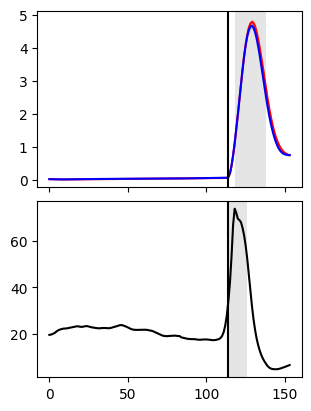

In [142]:
excr_high, excr_low = [], []
for s, ses in enumerate(df_excr.session.unique()):
    ses_idx = df_excr.session==ses
    df_excr_ses = df_excr[ses_idx]
    excr_ses = excr[ses_idx]
    thresh = np.median(df_excr_ses.peak_pe)
    high = df_excr_ses.peak_pe > thresh
    low = ~high
    excr_high.append(excr_ses[high].mean(axis=0))
    excr_low.append(excr_ses[low].mean(axis=0))

excr_high, excr_low = np.stack(excr_high).T, np.stack(excr_low).T

fig, axs = plt.subplots(2, sharex=True, figsize=(3, 4), constrained_layout=True)

t_cue = np.linspace(0, gl.cuePost - 1, gl.cuePost)
t_pert = np.linspace(gl.pertPre, gl.pertPost - 1, gl.pertPost - gl.pertPre) #+ 5
t = np.concatenate((t_cue, t_pert))

excr_high_avg = excr_high.mean(axis=1)
excr_low_avg = excr_low.mean(axis=1)
excr_high_err = excr_high.std(axis=1) / np.sqrt(len(excr_high))
excr_low_err = excr_low.std(axis=1) / np.sqrt(len(excr_low))

ax = axs[0]
ax.plot(t, excr_high_avg, color='r')
ax.fill_between(t, excr_high_avg - excr_high_err, excr_high_avg + excr_high_err, color='r', alpha=0.2, lw=0)
ax.plot(t, excr_low_avg, color='b')
ax.fill_between(t, excr_low_avg - excr_low_err, excr_low_avg + excr_low_err, color='b', alpha=0.2, lw=0)
ax.axvspan(gl.pertIdx + 4, gl.pertIdx + 24, color='grey', alpha=0.2, lw=0)
ax.axvline(gl.pertIdx, color='k')

ax = axs[1]
ax.plot(t, pe.mean(axis=0), color='k')
ax.axvspan(gl.pertIdx, gl.pertIdx + 12, color='grey', alpha=0.2, lw=0)
ax.axvline(gl.pertIdx, color='k')